In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.dirname(os.path.abspath('.')))

from sqlalchemy import text
from db.database import engine
from etl.constants import EUROPEAN_COUNTRIES, DECOUPLING_START_YEAR

In [2]:
# What we have
query = """
    SELECT 
        c.name as country,
        c.iso_code,
        c.continent,
        c.region,
        e.year,
        e.co2_total,
        e.co2_per_capita,
        e.co2_per_gdp,
        e.consumption_co2,
        e.consumption_co2_per_gdp,
        e.trade_co2,
        e.trade_co2_share,
        e.gdp,
        e.population,
        e.temperature_change_from_co2
    FROM emissions e
    JOIN countries c ON c.id = e.country_id
    ORDER BY c.iso_code, e.year;
"""

with engine.connect() as conn:
    df = pd.read_sql(text(query), conn)

print(f"Total rows: {len(df)}")
print(f"Countries: {df['iso_code'].nunique()}")
print(f"Years: {df['year'].min()} - {df['year'].max()}")

2026-06-06 22:38:59,582 INFO sqlalchemy.engine.Engine select pg_catalog.version()
2026-06-06 22:38:59,582 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-06-06 22:38:59,596 INFO sqlalchemy.engine.Engine select current_schema()
2026-06-06 22:38:59,597 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-06-06 22:38:59,602 INFO sqlalchemy.engine.Engine show standard_conforming_strings
2026-06-06 22:38:59,603 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-06-06 22:38:59,606 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-06-06 22:38:59,613 INFO sqlalchemy.engine.Engine SELECT pg_catalog.pg_class.relname 
FROM pg_catalog.pg_class JOIN pg_catalog.pg_namespace ON pg_catalog.pg_namespace.oid = pg_catalog.pg_class.relnamespace 
WHERE pg_catalog.pg_class.relname = %(table_name)s AND pg_catalog.pg_class.relkind = ANY (ARRAY[%(param_1)s, %(param_2)s, %(param_3)s, %(param_4)s, %(param_5)s]) AND pg_catalog.pg_table_is_visible(pg_catalog.pg_class.oid) AND pg_catalog.pg_namespace.nspname != %(nspname

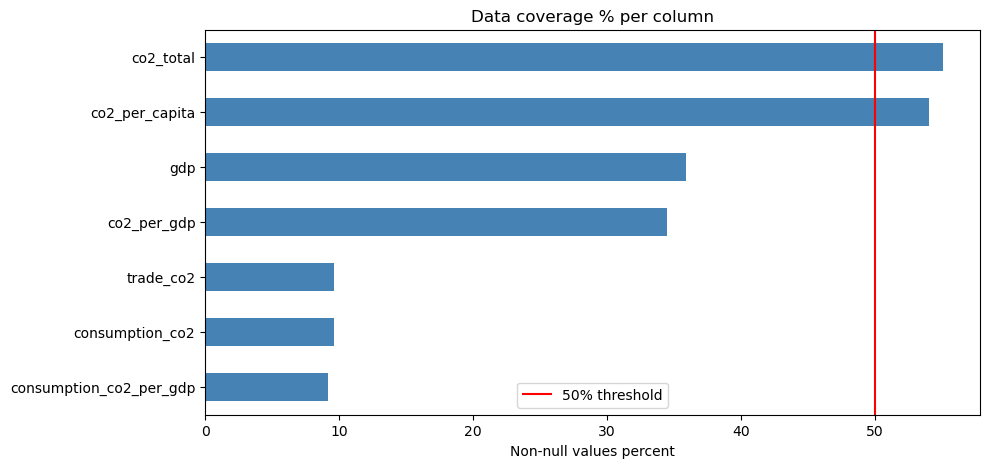

consumption_co2_per_gdp     9.2
consumption_co2             9.6
trade_co2                   9.6
co2_per_gdp                34.5
gdp                        35.9
co2_per_capita             54.0
co2_total                  55.1
dtype: float64


In [3]:
# Data coverage percent
key_cols = [
    'co2_total', 'co2_per_capita', 'co2_per_gdp',
    'consumption_co2', 'consumption_co2_per_gdp',
    'trade_co2', 'gdp'
]

coverage = (df[key_cols].notna().sum() / len(df) * 100).round(1)
coverage = coverage.sort_values(ascending=True)

plt.figure(figsize=(10, 5))
coverage.plot(kind='barh', color='steelblue')
plt.title('Data coverage % per column')
plt.xlabel('Non-null values percent')
plt.axvline(x=50, color='red', linestyle='-', label='50% threshold')
plt.legend()
plt.show()

print(coverage)

In [4]:
# Key metrics only exist from 1990
df_modern = df[df['year'] >= 1990].copy()

coverage_modern = (df_modern[key_cols].notna().sum() / len(df_modern) * 100).round(1)

print("Coverage 1990+:")
print(coverage_modern.sort_values(ascending=True))
print(f"\nRows after 1990 filter: {len(df_modern)}")
print(f"Countries after 1990 filter: {df_modern['iso_code'].nunique()}")

Coverage 1990+:
consumption_co2_per_gdp    51.2
consumption_co2            53.3
trade_co2                  53.3
co2_per_gdp                70.9
gdp                        70.9
co2_per_capita             97.5
co2_total                  98.4
dtype: float64

Rows after 1990 filter: 7630
Countries after 1990 filter: 218


In [5]:
# For decoupling analysis we need BOTH consumption_co2 AND gdp
# Find countries where both exist for at least 10 years after 1990

decoupling_ready = (
    df_modern
    .groupby('iso_code')
    .apply(lambda x: pd.Series({
        'country': x['country'].iloc[0],
        'years_with_co2': x['co2_total'].notna().sum(),
        'years_with_consumption_co2': x['consumption_co2'].notna().sum(),
        'years_with_gdp': x['gdp'].notna().sum(),
        'years_with_both': (x['consumption_co2'].notna() & x['gdp'].notna()).sum(),
        'year_start': x.loc[x['consumption_co2'].notna(), 'year'].min() if x['consumption_co2'].notna().any() else None,
        'year_end': x.loc[x['consumption_co2'].notna(), 'year'].max() if x['consumption_co2'].notna().any() else None,
    }))
    .reset_index()
)

full_data = decoupling_ready[decoupling_ready['years_with_both'] >= 10].sort_values('years_with_both', ascending=False)

print(f"Countries with 10+ years of full decoupling data: {len(full_data)}")
print(full_data[['country', 'years_with_both', 'year_start', 'year_end']].to_string())

Countries with 10+ years of full decoupling data: 119
                  country  years_with_both  year_start  year_end
4                 Albania               33      1990.0    2023.0
7               Argentina               33      1990.0    2023.0
8                 Armenia               33      1990.0    2023.0
12                Austria               33      1990.0    2023.0
11              Australia               33      1990.0    2023.0
13             Azerbaijan               33      1990.0    2023.0
15                Belgium               33      1990.0    2023.0
28                 Brazil               33      1990.0    2023.0
16                  Benin               33      1990.0    2023.0
18           Burkina Faso               33      1990.0    2023.0
19             Bangladesh               33      1990.0    2023.0
20               Bulgaria               33      1990.0    2023.0
21                Bahrain               33      1990.0    2023.0
24                Belarus           

In [ ]:
# Pull urbanization data too for Europe check
urban_query = """
    SELECT 
        c.name as country,
        c.iso_code,
        u.year,
        u.urban_population_pct,
        u.population_density,
        u.pm25_exposure
    FROM urbanization u
    JOIN countries c ON c.id = u.country_id
"""

with engine.connect() as conn:
    df_urban = pd.read_sql(text(urban_query), conn)


df_eu = df_modern[df_modern['iso_code'].isin(EUROPEAN_COUNTRIES)]

eu_coverage = (
    df_eu.groupby('iso_code')
    .apply(lambda x: pd.Series({
        'country': x['country'].iloc[0],
        'years_with_both': (x['consumption_co2'].notna() & x['gdp'].notna()).sum(),
    }))
    .reset_index()
    .sort_values('years_with_both', ascending=False)
)

print("European countries - decoupling data availability:")
print(eu_coverage[['country', 'years_with_both']].to_string())

2026-06-06 22:46:41,390 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-06-06 22:46:41,392 INFO sqlalchemy.engine.Engine SELECT pg_catalog.pg_class.relname 
FROM pg_catalog.pg_class JOIN pg_catalog.pg_namespace ON pg_catalog.pg_namespace.oid = pg_catalog.pg_class.relnamespace 
WHERE pg_catalog.pg_class.relname = %(table_name)s AND pg_catalog.pg_class.relkind = ANY (ARRAY[%(param_1)s, %(param_2)s, %(param_3)s, %(param_4)s, %(param_5)s]) AND pg_catalog.pg_table_is_visible(pg_catalog.pg_class.oid) AND pg_catalog.pg_namespace.nspname != %(nspname_1)s
2026-06-06 22:46:41,394 INFO sqlalchemy.engine.Engine [cached since 461.8s ago] {'table_name': <sqlalchemy.sql.elements.TextClause object at 0x000002C368C8CCD0>, 'param_1': 'r', 'param_2': 'p', 'param_3': 'f', 'param_4': 'v', 'param_5': 'm', 'nspname_1': 'pg_catalog'}
2026-06-06 22:46:41,397 INFO sqlalchemy.engine.Engine 
    SELECT 
        c.name as country,
        c.iso_code,
        u.year,
        u.urban_population_pct,
        u.po

In [12]:
import json

# Countries ready for decoupling analysis
decoupling_countries = full_data['iso_code'].tolist()

# European countries with full data
eu_full = eu_coverage[eu_coverage['years_with_both'] >= 10]['iso_code'].tolist()

print("FINAL DATA QUALITY SUMMARY")

print(f"\n Rows in DB total:                    {len(df)}")
print(f" Countries total:                     {df['iso_code'].nunique()}")
print(f" Decoupling-ready countries:          {len(decoupling_countries)}")
print(f" European countries with full data:   {len(eu_full)}")
print(f" Usable year range:                   1990–2023")
print(f"\n Next step: Notebook 04 - Decoupling Analysis")
print(f" Focus: {len(decoupling_countries)} countries × 33 years")
print(f" European deep dive: {len(eu_full)} countries")

FINAL DATA QUALITY SUMMARY

 Rows in DB total:                    42480
 Countries total:                     218
 Decoupling-ready countries:          119
 European countries with full data:   34
 Usable year range:                   1990–2023

 Next step: Notebook 04 - Decoupling Analysis
 Focus: 119 countries × 33 years
 European deep dive: 34 countries
